# Blok A — Sebaran metrik

Melengkapi `analisis_blok_A_klaim_utama.ipynb` dengan **sebaran**, bukan hanya rerata.
Seluruh lengan setara: `FormulaForecaster`, k=3, kanal janji dibatasi.

**Dua jenis sebaran yang tidak boleh tertukar:**

| | Sumber | Menjawab |
|---|---|---|
| **antar-unit** | checkpoint (RL, n=3) / run (greedy, n=10) | seberapa stabil bila diulang? |
| **dalam-run** | persentil antar pengguna/trip di dalam satu run | apakah beban ditanggung merata? |

> **Ketidakseimbangan n.** greedy 10 run, lengan RL 3 checkpoint (melatih ulang tak
> memungkinkan). Perbandingan **rerata** sah; perbandingan **lebar sebaran** condong
> menguntungkan lengan ber-n kecil — n=3 cenderung memberi rentang teramati lebih
> sempit dari yang sebenarnya. Jangan simpulkan "RL lebih stabil" dari SD saja.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _analisis_bab5 as A

pd.set_option('display.width', 230); pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': .3})

HORIZON = '90d'
B = 'master_hybrid_ppo_dgr_90d_cwtfail120pen-2_preffeat_pairout'
LENGAN = [('sel1 mati',    f'{B}_noattn_pure3',       None),
          ('sel2 attn',    f'{B}_pure3',              None),
          ('sel3 P',       f'{B}_pg0.1_noattn_pure3', None),
          ('sel4 attn+P',  f'{B}_pg0.1_pure3',        None),
          ('greedy_queue', 'greedy_setara_k3', 'greedy_queue|signed|dinamis')]

# `gini_UTIL` (metrik TK1 yang benar) dihitung dari `_stasiun`, bukan tersimpan
# sebagai metrik biasa -- dibungkus agar antarmukanya seragam dgn `unit_stat`.
def nilai(tag, m, lengan=None):
    if m == 'gini_UTIL':  return A.gini_stasiun(tag, 'gini_utilisasi', HORIZON, lengan)
    if m == 'gini_ANTRE': return A.gini_stasiun(tag, 'gini_antrean',   HORIZON, lengan)
    return A.unit_stat(tag, m, HORIZON, lengan)

METRIK = ['gini_UTIL', 'gini_ANTRE', 'gini_wait_pengguna', 'acc', 'wait', 'trust',
          'rec_entropy', 'herding', 'pct_tepat',
          'jnpatuh_expost_frac_untung', 'jnpatuh_expost_mean',
          'pref_dalam', 'pref_primer', 'patuh_bila_pref_tiada']
A.ARAH_BAIK.update({'gini_UTIL': 'min', 'gini_ANTRE': 'min',
                    'pref_dalam': 'max', 'pref_primer': 'max',
                    'patuh_bila_pref_tiada': 'max'})

for n, t, l in LENGAN:
    v = nilai(t, 'gini_UTIL', l)
    print(f'{n:14s} n={len(v[2]):2d} unit={v[3]}')

sel1 mati      n= 3 unit=checkpoint
sel2 attn      n= 3 unit=checkpoint
sel3 P         n= 3 unit=checkpoint
sel4 attn+P    n= 3 unit=checkpoint
greedy_queue   n=10 unit=run


## 1. Sebaran antar-unit — ringkasan

`cv` = sd/|mean| (koefisien variasi, membandingkan kestabilan lintas metrik bersatuan
berbeda). Kolom `nilai` menampilkan **seluruh** nilai per-unit apa adanya — dengan n
kecil, meringkasnya menyesatkan.

In [2]:
baris = []
for n, t, l in LENGAN:
    for m in METRIK:
        mean, sd, v, lab = nilai(t, m, l)
        baris.append({'metrik': m, 'lengan': n, 'unit': lab, 'n': len(v),
                      'mean': mean, 'sd': sd, 'min': float(v.min()),
                      'median': float(np.median(v)), 'maks': float(v.max()),
                      'cv': sd / abs(mean) if mean else np.nan,
                      'nilai': np.round(v, 4).tolist()})
seb = pd.DataFrame(baris).set_index(['metrik', 'lengan'])
display(seb[['unit', 'n', 'mean', 'sd', 'min', 'median', 'maks', 'cv']].round(4))

,,unit,n,mean,sd,min,median,maks,cv
metrik,lengan,,,,,,,,
gini_UTIL,sel1 mati,checkpoint,3,0.0289,0.0094,0.0188,0.0265,0.0415,0.3264
gini_ANTRE,sel1 mati,checkpoint,3,0.0929,0.0282,0.0622,0.0863,0.1303,0.3034
gini_wait_pengguna,sel1 mati,checkpoint,3,0.3870,0.0192,0.3714,0.3756,0.4141,0.0497
acc,sel1 mati,checkpoint,3,0.6700,0.0257,0.6370,0.6734,0.6997,0.0383
wait,sel1 mati,checkpoint,3,95.9557,17.6121,76.3841,92.4001,119.0828,0.1835
...,...,...,...,...,...,...,...,...,...
jnpatuh_expost_frac_untung,greedy_queue,run,10,0.4074,0.0046,0.3960,0.4084,0.4140,0.0113
jnpatuh_expost_mean,greedy_queue,run,10,11.0938,0.5037,9.8343,11.2174,11.7569,0.0454
pref_dalam,greedy_queue,run,10,0.4954,0.0027,0.4922,0.4951,0.5010,0.0055


In [3]:
for m in METRIK:
    print(f'\n{m}')
    for n, t, l in LENGAN:
        print(f'   {n:14s} {np.round(nilai(t, m, l)[2], 4).tolist()}')


gini_UTIL
   sel1 mati      [0.0265, 0.0415, 0.0188]
   sel2 attn      [0.0562, 0.026, 0.0357]
   sel3 P         [0.0668, 0.0529, 0.0368]
   sel4 attn+P    [0.0171, 0.0273, 0.0174]
   greedy_queue   [0.119, 0.1203, 0.1127, 0.1156, 0.1144, 0.1172, 0.1147, 0.1165, 0.1147, 0.1182]

gini_ANTRE
   sel1 mati      [0.1303, 0.0863, 0.0622]
   sel2 attn      [0.1461, 0.0574, 0.1613]
   sel3 P         [0.1948, 0.1432, 0.0959]
   sel4 attn+P    [0.0583, 0.0631, 0.0856]
   greedy_queue   [0.234, 0.2191, 0.2083, 0.2193, 0.211, 0.2438, 0.2037, 0.2322, 0.2272, 0.233]

gini_wait_pengguna
   sel1 mati      [0.3714, 0.4141, 0.3756]
   sel2 attn      [0.3728, 0.4169, 0.4112]
   sel3 P         [0.3996, 0.3897, 0.4033]
   sel4 attn+P    [0.417, 0.4111, 0.3974]
   greedy_queue   [0.5085, 0.5052, 0.5044, 0.5122, 0.5044, 0.5093, 0.5061, 0.5098, 0.4996, 0.506]

acc
   sel1 mati      [0.6734, 0.6997, 0.637]
   sel2 attn      [0.6479, 0.7301, 0.7282]
   sel3 P         [0.7026, 0.68, 0.7276]
   sel4 attn+P    [0

   sel1 mati      [0.3607, 0.3992, 0.34]
   sel2 attn      [0.3291, 0.4379, 0.4135]
   sel3 P         [0.3891, 0.3603, 0.4387]
   sel4 attn+P    [0.4375, 0.4406, 0.4262]
   greedy_queue   [0.4323, 0.4372, 0.4339, 0.443, 0.4313, 0.441, 0.4314, 0.4402, 0.4356, 0.4396]

rec_entropy
   sel1 mati      [0.0644, 0.0594, 0.0569]
   sel2 attn      [0.0595, 0.1074, 0.0695]
   sel3 P         [0.058, 0.0516, 0.1144]
   sel4 attn+P    [0.1187, 0.1359, 0.1001]
   greedy_queue   [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

herding
   sel1 mati      [0.3616, 0.368, 0.3677]
   sel2 attn      [0.3662, 0.317, 0.3581]
   sel3 P         [0.3678, 0.3748, 0.307]
   sel4 attn+P    [0.3029, 0.2895, 0.3265]
   greedy_queue   [0.4294, 0.4258, 0.4254, 0.4255, 0.4272, 0.427, 0.4217, 0.4244, 0.4243, 0.4248]

pct_tepat
   sel1 mati      [22.6803, 36.7135, 25.3645]
   sel2 attn      [23.3178, 43.189, 38.4851]
   sel3 P         [30.6274, 31.7605, 41.4246]
   sel4 attn+P    [39.9102, 38.4974, 34.7084]
   greedy_

   sel1 mati      [21.1213, 18.4177, 13.2709]
   sel2 attn      [16.1938, 16.5116, 19.2575]
   sel3 P         [21.8098, 13.5929, 17.6455]
   sel4 attn+P    [18.9413, 22.4061, 20.6906]
   greedy_queue   [11.7569, 10.8149, 11.2194, 11.5857, 11.2253, 11.2154, 10.939, 11.4041, 9.8343, 10.9427]

pref_dalam
   sel1 mati      [0.5051, 0.5047, 0.4611]
   sel2 attn      [0.4861, 0.5127, 0.55]
   sel3 P         [0.5308, 0.5015, 0.5223]
   sel4 attn+P    [0.5115, 0.5063, 0.5198]
   greedy_queue   [0.496, 0.4977, 0.4941, 0.4941, 0.4922, 0.4965, 0.4977, 0.501, 0.4922, 0.4929]

pref_primer
   sel1 mati      [0.1639, 0.1686, 0.1528]
   sel2 attn      [0.1558, 0.164, 0.2195]
   sel3 P         [0.1805, 0.1722, 0.1794]
   sel4 attn+P    [0.1691, 0.1644, 0.1757]
   greedy_queue   [0.1617, 0.1646, 0.1611, 0.1574, 0.1595, 0.1636, 0.1598, 0.1638, 0.1575, 0.1582]

patuh_bila_pref_tiada
   sel1 mati      [0.3727, 0.424, 0.3493]
   sel2 attn      [0.3422, 0.4784, 0.4382]
   sel3 P         [0.4034, 0.3866, 0.46

## 2. Sebaran antar-unit — visual

Titik individual, bukan diagram batang ±SD. Dengan n=3 pada lengan RL, batang-ralat
menyiratkan distribusi yang tak dapat diperkirakan dari 3 titik; titik mentah
menunjukkan struktur apa adanya (termasuk bimodalitas bila ada).

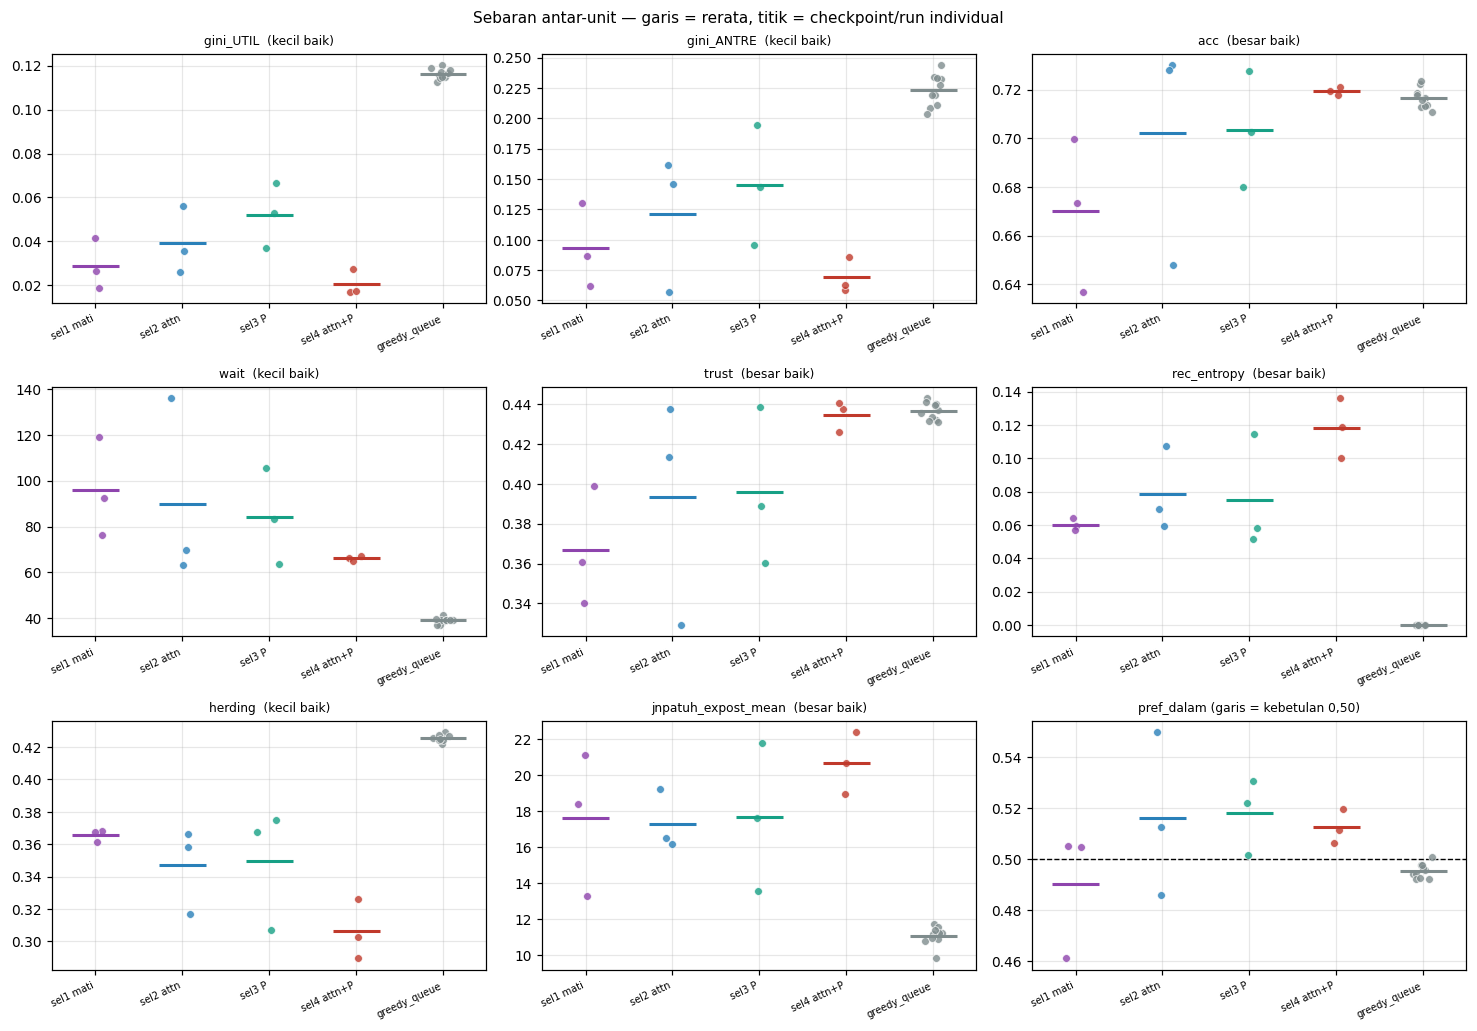

In [4]:
warna = ['#8e44ad', '#2980b9', '#16a085', '#c0392b', '#7f8c8d', '#d35400']
tampil = ['gini_UTIL', 'gini_ANTRE', 'acc', 'wait', 'trust', 'rec_entropy',
          'herding', 'jnpatuh_expost_mean', 'pref_dalam']
fig, axes = plt.subplots(3, 3, figsize=(13.5, 9.5))
rng = np.random.default_rng(0)
for ax, m in zip(axes.ravel(), tampil):
    for i, (n, t, l) in enumerate(LENGAN):
        v = nilai(t, m, l)[2]
        ax.scatter(rng.normal(i, .06, len(v)), v, s=26, alpha=.8, color=warna[i],
                   edgecolor='white', linewidth=.5, zorder=3)
        ax.hlines(v.mean(), i - .27, i + .27, color=warna[i], lw=2, zorder=4)
    if m == 'pref_dalam':
        ax.axhline(0.5, color='k', ls='--', lw=.9)
        ax.set_title('pref_dalam (garis = kebetulan 0,50)', fontsize=8)
    else:
        arah = A.ARAH_BAIK.get(m, '')
        ket = 'kecil baik' if arah == 'min' else 'besar baik' if arah == 'max' else ''
        ax.set_title(f'{m}  ({ket})', fontsize=8)
    ax.set_xticks(range(len(LENGAN)))
    ax.set_xticklabels([n for n, _, _ in LENGAN], rotation=25, ha='right', fontsize=6.5)
plt.suptitle('Sebaran antar-unit — garis = rerata, titik = checkpoint/run individual',
             fontsize=10)
plt.tight_layout(); plt.show()

## 3. Sebaran dalam-run — waktu tunggu

Rerata `wait` yang sama dapat menyembunyikan ekor yang sangat berbeda. `wpatuh` vs
`wtolak` memisahkan yang **menuruti** dari yang **menolak** — waktu tunggu penolak
bukan konsekuensi rekomendasi, jadi mencampurnya adalah salah atribusi.

In [5]:
for dasar, judul in [('w', 'SELURUH trip'), ('wpatuh', 'trip PATUH'),
                     ('wtolak', 'trip MENOLAK')]:
    print(f'\n=== waktu tunggu (menit) — {judul} ===')
    display(A.profil_dalam_run(LENGAN, dasar, HORIZON).round(2))


=== waktu tunggu (menit) — SELURUH trip ===


,min,p10,p25,p50,p75,p90,p95,p99,maks
lengan,,,,,,,,,
sel1 mati,0.0,0.0,0.0,56.34,152.31,256.28,327.06,492.60,1071.81
sel2 attn,0.0,0.0,0.0,49.49,143.33,246.40,314.51,460.64,976.35
sel3 P,0.0,0.0,0.0,46.90,132.82,229.83,295.08,443.28,928.20
sel4 attn+P,0.0,0.0,0.0,36.06,103.74,180.93,235.60,364.70,881.89
greedy_queue,0.0,0.0,0.0,0.00,57.15,121.43,170.67,296.00,617.90



=== waktu tunggu (menit) — trip PATUH ===


,min,p10,p25,p50,p75,p90,p95,p99,maks
lengan,,,,,,,,,
sel1 mati,0.0,0.0,0.00,68.70,156.64,253.84,322.06,471.32,905.38
sel2 attn,0.0,0.0,3.77,54.10,144.63,240.08,301.37,431.94,850.83
sel3 P,0.0,0.0,0.00,43.95,125.67,214.88,277.17,419.03,802.57
sel4 attn+P,0.0,0.0,0.00,23.04,79.67,146.21,192.85,299.26,728.94
greedy_queue,0.0,0.0,0.00,0.00,34.85,79.84,114.24,195.34,503.36



=== waktu tunggu (menit) — trip MENOLAK ===


,min,p10,p25,p50,p75,p90,p95,p99,maks
lengan,,,,,,,,,
sel1 mati,0.0,0.0,0.00,46.52,138.98,241.79,319.18,526.89,1037.31
sel2 attn,0.0,0.0,6.43,56.95,142.50,242.57,315.45,493.01,906.22
sel3 P,0.0,0.0,8.88,67.88,150.21,243.19,310.24,491.81,892.74
sel4 attn+P,0.0,0.0,4.15,84.02,160.70,244.01,302.28,463.55,878.28
greedy_queue,0.0,0.0,0.00,51.43,119.28,194.09,251.89,392.34,612.47


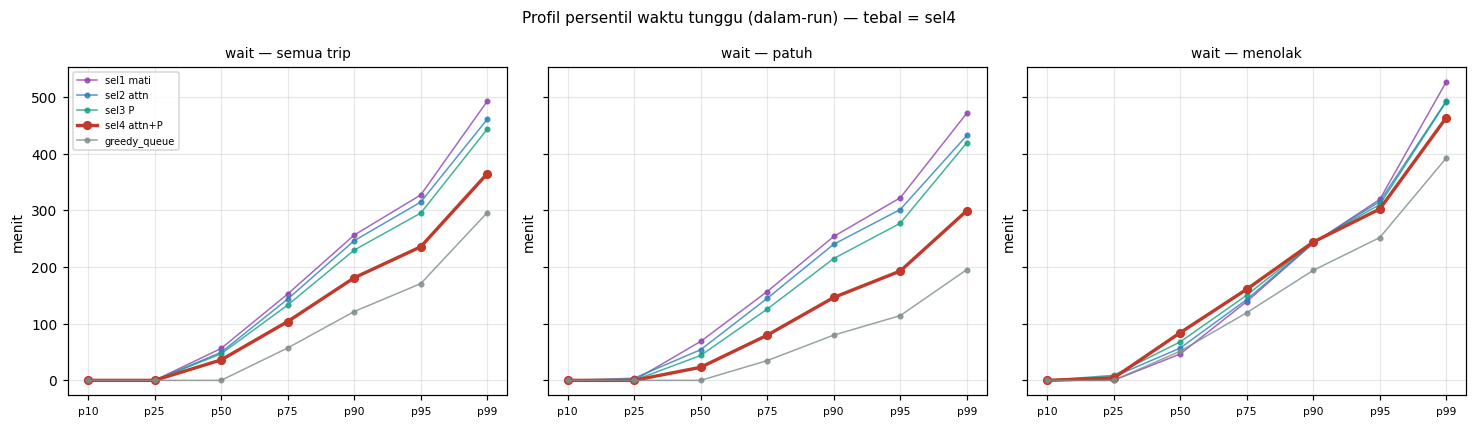

Ekor kanan (p90-p99) menentukan pengalaman terburuk; rerata menyembunyikannya.


In [6]:
pers = ['p10', 'p25', 'p50', 'p75', 'p90', 'p95', 'p99']
x = np.arange(len(pers))
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9), sharey=True)
for ax, (dasar, judul) in zip(axes, [('w', 'semua trip'), ('wpatuh', 'patuh'),
                                      ('wtolak', 'menolak')]):
    prof = A.profil_dalam_run(LENGAN, dasar, HORIZON)
    for i, n in enumerate(prof.index):
        gaya = dict(lw=2.2, ms=5) if n == 'sel4 attn+P' else dict(lw=1, ms=3, alpha=.8)
        ax.plot(x, prof.loc[n, pers].to_numpy(float), marker='o', label=n,
                color=warna[i], **gaya)
    ax.set_xticks(x); ax.set_xticklabels(pers, fontsize=7)
    ax.set_title(f'wait — {judul}', fontsize=9); ax.set_ylabel('menit')
axes[0].legend(fontsize=6.5)
plt.suptitle('Profil persentil waktu tunggu (dalam-run) — tebal = sel4', fontsize=10)
plt.tight_layout(); plt.show()
print('Ekor kanan (p90-p99) menentukan pengalaman terburuk; rerata menyembunyikannya.')

## 4. Sebaran dalam-run — kepercayaan & galat janji

`tr_*` = sebaran trust antar **pengguna** di akhir simulasi.

> **Catatan (AUDIT_METRIK.md §2.1):** `tr_p50 = 0,5000` persis di semua lengan karena
> 24,2% pengguna tak pernah mengalami pembaruan trust dan tetap di prior. Massa titik
> itu melewati median. Pengenceran identik di semua lengan sehingga urutan tetap sah.

In [7]:
print('=== trust antar pengguna ===')
display(A.profil_dalam_run(LENGAN, 'tr', HORIZON).round(4))
print('\n=== galat janji (menit; positif = menunggu lebih lama dari janji) ===')
display(A.profil_dalam_run(LENGAN, 'galat', HORIZON).round(2))

=== trust antar pengguna ===


,min,p10,p25,p50,p75,p90,p95,p99,maks
lengan,,,,,,,,,
sel1 mati,0.0334,0.1186,0.1945,0.4191,0.5040,0.5696,0.5819,0.6651,0.7673
sel2 attn,0.0358,0.1483,0.2385,0.4395,0.5334,0.5984,0.6162,0.6744,0.7726
sel3 P,0.0375,0.1480,0.2394,0.4656,0.5217,0.5819,0.6286,0.6847,0.7871
sel4 attn+P,0.0468,0.1888,0.3070,0.5000,0.5546,0.6098,0.6423,0.7054,0.8043
greedy_queue,0.0529,0.1935,0.2994,0.5000,0.5652,0.6154,0.6552,0.7302,0.8358



=== galat janji (menit; positif = menunggu lebih lama dari janji) ===


,min,p10,p25,p50,p75,p90,p95,p99,maks
lengan,,,,,,,,,
sel1 mati,-293.37,-66.48,-35.06,0.0,11.88,64.23,101.67,194.70,558.41
sel2 attn,-284.20,-61.29,-32.60,0.0,8.47,54.61,88.92,175.78,463.97
sel3 P,-278.26,-61.00,-32.40,0.0,6.10,50.34,85.35,173.25,488.95
sel4 attn+P,-236.35,-55.33,-33.08,0.0,0.00,31.60,60.01,133.95,419.71
greedy_queue,-189.71,-47.19,-7.77,0.0,0.00,38.04,65.91,133.92,421.87


## 5. Tumpang tindih sebaran

Dengan n kecil, pertanyaan yang lebih jujur daripada "apakah signifikan" adalah
**"apakah rentangnya beririsan"**. Bila rentang teramati kedua lengan tidak beririsan
sama sekali, perbedaannya konsisten pada seluruh pengulangan yang ada — pernyataan yang
dapat dipertanggungjawabkan tanpa mengklaim nilai-p.

In [8]:
baris = []
for m in METRIK:
    vu = nilai(LENGAN[3][1], m, LENGAN[3][2])[2]      # sel4
    for n, t, l in LENGAN[:3] + LENGAN[4:]:
        vg = nilai(t, m, l)[2]
        tindih = not (vu.max() < vg.min() or vg.max() < vu.min())
        arah = A.ARAH_BAIK.get(m, '?')
        menang = '-' if tindih else (
            'sel4' if ((vu.max() < vg.min()) == (arah == 'min')) else n)
        baris.append({'metrik': m, 'sel4 vs': n, 'arah': arah,
                      'rentang_sel4': f'[{vu.min():.4g}, {vu.max():.4g}]',
                      'rentang_lawan': f'[{vg.min():.4g}, {vg.max():.4g}]',
                      'tumpang_tindih': tindih, 'yang_unggul': menang})
tt = pd.DataFrame(baris)
display(tt.set_index(['metrik', 'sel4 vs']))

arah       rentang_sel4       rentang_lawan  tumpang_tindih   yang_unggul
metrik                     sel4 vs                                                                               
gini_UTIL                  sel1 mati     min  [0.01714, 0.0273]   [0.01877, 0.0415]            True             -
                           sel2 attn     min  [0.01714, 0.0273]  [0.02596, 0.05616]            True             -
                           sel3 P        min  [0.01714, 0.0273]   [0.0368, 0.06676]           False          sel4
                           greedy_queue  min  [0.01714, 0.0273]    [0.1127, 0.1203]           False          sel4
gini_ANTRE                 sel1 mati     min  [0.0583, 0.08559]   [0.06218, 0.1303]            True             -
                           sel2 attn     min  [0.0583, 0.08559]   [0.05737, 0.1613]            True             -
                           sel3 P        min  [0.0583, 0.08559]   [0.09592, 0.1948]           False          sel4
                           greedy_queue  min  [0.0583, 0.08559]    [0.2037, 0.2438]           False          sel4
gini_wait_pengguna         sel1 mati     min    [0.3974, 0.417]    [0.3714, 0.4141]            True             -
                           sel2 attn     min    [0.3974, 0.417]    [0.3728, 0.4169]            True             -
                           sel3 P        min    [0.3974, 0.417]    [0.3897, 0.4033]            True             -
                           greedy_queue  min    [0.3974, 0.417]    [0.4996, 0.5122]           False          sel4
acc                        sel1 mati     max   [0.7178, 0.7211]     [0.637, 0.6997]           False          sel4
                           sel2 attn     max   [0.7178, 0.7211]    [0.6479, 0.7301]            True             -
                           sel3 P        max   [0.7178, 0.7211]      [0.68, 0.7276]            True             -
                           greedy_queue  max   [0.7178, 0.7211]    [0.7109, 0.7237]            True             -
wait                       sel1 mati     min     [65.19, 67.11]      [76.38, 119.1]           False          sel4
                           sel2 attn     min     [65.19, 67.11]      [63.46, 135.9]            True             -
                           sel3 P        min     [65.19, 67.11]      [63.57, 105.6]            True             -
                           greedy_queue  min     [65.19, 67.11]      [37.08, 41.62]           False  greedy_queue
trust                      sel1 mati     max   [0.4262, 0.4406]      [0.34, 0.3992]           False          sel4
                           sel2 attn     max   [0.4262, 0.4406]    [0.3291, 0.4379]            True             -
                           sel3 P        max   [0.4262, 0.4406]    [0.3603, 0.4387]            True             -
                           greedy_queue  max   [0.4262, 0.4406]     [0.4313, 0.443]            True             -
rec_entropy                sel1 mati     max   [0.1001, 0.1359]  [0.05688, 0.06442]           False          sel4
                           sel2 attn     max   [0.1001, 0.1359]   [0.05949, 0.1074]            True             -
                           sel3 P        max   [0.1001, 0.1359]   [0.05156, 0.1144]            True             -
                           greedy_queue  max   [0.1001, 0.1359]              [0, 0]           False          sel4
herding                    sel1 mati     min   [0.2895, 0.3265]     [0.3616, 0.368]           False          sel4
                           sel2 attn     min   [0.2895, 0.3265]     [0.317, 0.3662]            True             -
                           sel3 P        min   [0.2895, 0.3265]     [0.307, 0.3748]            True             -
                           greedy_queue  min   [0.2895, 0.3265]    [0.4217, 0.4294]           False          sel4
pct_tepat                  sel1 mati     max     [34.71, 39.91]      [22.68, 36.71]            True             -
                           sel2 attn     max     [

In [9]:
vs_greedy = tt[tt['sel4 vs'].str.startswith('greedy')]
menang = vs_greedy[(~vs_greedy['tumpang_tindih']) & (vs_greedy['yang_unggul'] == 'sel4')]
kalah  = vs_greedy[(~vs_greedy['tumpang_tindih']) & (vs_greedy['yang_unggul'] != 'sel4')]
tind   = vs_greedy[vs_greedy['tumpang_tindih']]

print('sel4 vs greedy_queue — hanya metrik dgn rentang TERPISAH yang boleh diklaim\n')
for judul, sub in [('UNGGUL (terpisah)', menang), ('KALAH (terpisah)', kalah),
                   ('TUMPANG TINDIH (jangan diklaim)', tind)]:
    m = sorted(set(sub['metrik']))
    print(f'{judul}: {len(m)} metrik')
    for x in m:
        n_pisah = (sub['metrik'] == x).sum()
        print(f'   {x}' + ('' if n_pisah == 2 else '   (hanya thd satu greedy)'))
    print()

sel4 vs greedy_queue — hanya metrik dgn rentang TERPISAH yang boleh diklaim

UNGGUL (terpisah): 8 metrik
   gini_ANTRE   (hanya thd satu greedy)
   gini_UTIL   (hanya thd satu greedy)
   gini_wait_pengguna   (hanya thd satu greedy)
   herding   (hanya thd satu greedy)
   jnpatuh_expost_frac_untung   (hanya thd satu greedy)
   jnpatuh_expost_mean   (hanya thd satu greedy)
   pref_dalam   (hanya thd satu greedy)
   rec_entropy   (hanya thd satu greedy)

KALAH (terpisah): 2 metrik
   pct_tepat   (hanya thd satu greedy)
   wait   (hanya thd satu greedy)

TUMPANG TINDIH (jangan diklaim): 4 metrik
   acc   (hanya thd satu greedy)
   patuh_bila_pref_tiada   (hanya thd satu greedy)
   pref_primer   (hanya thd satu greedy)
   trust   (hanya thd satu greedy)



## 6. Sebaran antar-sel faktorial

Membandingkan keempat sel RL satu sama lain — menunjukkan mana yang perbedaannya
konsisten antar-checkpoint dan mana yang tidak.

In [10]:
sub = tt[~tt['sel4 vs'].str.startswith('greedy')]
print('sel4 vs sel LAIN (semua n=3, jadi keterpisahan lebih sulit dicapai)\n')
for m in METRIK:
    s = sub[sub['metrik'] == m]
    pisah = s[~s['tumpang_tindih']]
    if len(pisah):
        lawan = ', '.join(f"{r['sel4 vs']}({r['yang_unggul']})" for _, r in pisah.iterrows())
        print(f'   {m:28s} terpisah dari: {lawan}')
print()
print('Sisanya tumpang tindih -- dgn n=3 per sel, klaim antar-sel harus hati-hati.')
print('Bukti terkuat perbedaan antar-sel bukan dari sebaran hasil, melainkan dari')
print('dinamika pelatihan (kestabilan bobot DGR) -- lihat notebook klaim utama A.10.')

sel4 vs sel LAIN (semua n=3, jadi keterpisahan lebih sulit dicapai)

   gini_UTIL                    terpisah dari: sel3 P(sel4)
   gini_ANTRE                   terpisah dari: sel3 P(sel4)
   acc                          terpisah dari: sel1 mati(sel4)
   wait                         terpisah dari: sel1 mati(sel4)
   trust                        terpisah dari: sel1 mati(sel4)
   rec_entropy                  terpisah dari: sel1 mati(sel4)
   herding                      terpisah dari: sel1 mati(sel4)
   pref_dalam                   terpisah dari: sel1 mati(sel4)
   patuh_bila_pref_tiada        terpisah dari: sel1 mati(sel4)

Sisanya tumpang tindih -- dgn n=3 per sel, klaim antar-sel harus hati-hati.
Bukti terkuat perbedaan antar-sel bukan dari sebaran hasil, melainkan dari
dinamika pelatihan (kestabilan bobot DGR) -- lihat notebook klaim utama A.10.
